# Team Value Over Time

Team power ranking over time, one league per section — each shown two ways:

- **Normalized 1–99** (top): KTC's `/power-rankings/teams` scale (top team that week = 99). Matches the live page (±1). League-wide events (e.g. draft day) scale every team together, so this view tracks standing rather than level shifts.
- **Adjusted value, raw** (bottom): the underlying `prProcessV` sum — absolute roster strength (league-wide events do show here).

Both use KTC's `prProcessV` depth adjustment **including draft picks** (the *Include Picks* / `hrdp=0` view), on **Superflex + TE‑Premium** values (SF Standard fallback before TEP existed, ~pre‑2025‑10). A "vs league average" view (100 = average team) is also available via `plot_league(id, "rel_mean")`.

**Regular-season windows** are shaded gray (NFL Week 1 from nflverse schedules → that season's `fantasy_end`); **draft days** (startup dark-green, rookie green) are vertical lines in the offseason gaps. Each owner's line color is hashed from their `owner_id`, so the same manager keeps one color across leagues.

In [1]:
import os, sys, importlib
# robust import: works whether the kernel cwd is the repo root or analysis/
for _d in [os.getcwd(), os.path.join(os.getcwd(), "analysis")]:
    if os.path.isfile(os.path.join(_d, "fantasy_lib.py")):
        if _d not in sys.path:
            sys.path.insert(0, _d)
        break
import polars as pl
import matplotlib.pyplot as plt
import fantasy_lib as F
importlib.reload(F)          # pick up edits without restarting the kernel
import warnings
warnings.filterwarnings("ignore", message=".*Sortedness.*")
print("fantasy_lib:", F.__file__)

fantasy_lib: C:\Users\simer\Coding Project\Fantasy Analysis\analysis\fantasy_lib.py


In [2]:
# --- load ownership ledger, dims, and the value lens ---
ledger = F.load_ledger()
franchises, _ = F.load_dims()
fr_meta = franchises.select("franchise_id", "league_lineage_id", "current_team_name", "roster_id", "owner_id")

player_values = F.load_player_values_blend(qb_format="SF")          # SF/TEP, Standard before TEP era
pick_values   = F.load_pick_values_round("ktc", "SF", "Standard")   # round-level KTC pick values

# weekly grid from the start of value coverage through the latest valuation date
START = max(ledger["valid_from"].min(), player_values["valuation_date"].min().isoformat())
TODAY = player_values["valuation_date"].max().isoformat()
dates = sorted(set(F.weekly_dates(START, TODAY) + [TODAY]))

# KTC power ranking WITH picks (hrdp=0), per (lineage, date): has both adj_total and power_index
power = (F.team_power_index(ledger, dates, player_values, fr_meta, pick_values=pick_values)
          .join(fr_meta.select("franchise_id", "current_team_name", "owner_id").unique(subset=["franchise_id"]),
                on="franchise_id", how="left"))

# trim each lineage's startup ramp: the first week holds a partial roster (startup draft
# still filling; picks are minted ~a week later -> 0 picks on day 1), which causes a fake
# week-1->2 spike. Start each lineage at its first week reaching >=95% of its steady-state
# (median) asset count.
_lin = fr_meta.select("franchise_id", "league_lineage_id").unique(subset=["franchise_id"])
_counts = (F._holdings_by_date(ledger, dates).join(_lin, on="franchise_id", how="left")
           .group_by("league_lineage_id", "date").agg(pl.len().alias("n")))
_starts = (_counts.join(_counts.group_by("league_lineage_id").agg(pl.col("n").median().alias("med")),
                        on="league_lineage_id")
           .filter(pl.col("n") >= 0.95 * pl.col("med"))
           .group_by("league_lineage_id").agg(pl.col("date").min().alias("_start")))
power = (power.join(_starts, on="league_lineage_id", how="left")
         .filter(pl.col("date") >= pl.col("_start")).drop("_start"))

# normalize to the league average each week (100 = average team). Cancels league-wide
# events (draft pick-class injection, KTC rescales) so the chart reflects team standing,
# not league-level shifts; unlike the 1-99 view it does not pin the leader flat.
power = power.with_columns(
    (100 * pl.col("adj_total") / pl.col("adj_total").mean().over("league_lineage_id", "date"))
    .alias("rel_mean"))

events = F.load_league_events()              # draft days + season ends per lineage
season_starts = F.load_nfl_season_starts()   # NFL Week 1 per season (from nflverse schedules)
# in-season window per lineage/season: NFL Week 1 -> that season's fantasy_end
bands = (events.filter(pl.col("event_type") == "fantasy_end")
         .join(season_starts, on="season", how="inner")
         .select("league_lineage_id", "season", "season_start",
                 pl.col("event_date").alias("season_end")))

LEAGUE_NAMES = {
    "730630605066371072":  "Stuck in High School",
    "1131624152349323264": "Football Guys of Indianapolis",
    "1061511485920354304": "Sigma Chi Dynasty League",
}
print(f"{len(dates)} weekly points {START} -> {TODAY} | "
      f"{power['franchise_id'].n_unique()} teams across {power['league_lineage_id'].n_unique()} leagues")

250 weekly points 2021-09-07 -> 2026-06-15 | 34 teams across 3 leagues


In [3]:
import hashlib
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# metric: "power_index" (1-99 vs top), "rel_mean" (% of league-average team), "adj_total" (raw prProcessV sum)
_METRIC_LABEL = {"power_index": "Power index  (1-99, picks incl.)",
                 "rel_mean":    "Team value vs league avg  (100 = average team)",
                 "adj_total":   "Adjusted value  (prProcessV sum, picks incl.)"}
_METRIC_TITLE = {"power_index": "normalized 1-99 (vs top team)",
                 "rel_mean":    "relative to league average",
                 "adj_total":   "adjusted value (raw)"}

# draft-day vertical-guide styling
_EVENT_STYLE = {
    "startup_draft": dict(color="darkgreen", linestyle="--", linewidth=1.3, alpha=0.75),
    "rookie_draft":  dict(color="seagreen",  linestyle="--", linewidth=1.0, alpha=0.6),
}
_EVENT_LABEL = {"startup_draft": "Startup draft", "rookie_draft": "Rookie draft"}

# 16 well-spread, line-visible colors (Trubetskoy distinct set, lightest dropped)
PALETTE = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4", "#42d4f4",
           "#f032e6", "#bfef45", "#469990", "#9a6324", "#800000", "#808000",
           "#000075", "#a9a9a9", "#d81b60", "#5d3a9b"]

def _ohash(owner_id):
    return int(hashlib.md5(str(owner_id).encode()).hexdigest(), 16)

def league_owner_colors(owner_ids):
    """Assign each owner a palette color: hash -> preferred slot, bump to the nearest free
    slot on collision. Unique within a league always; the same owner usually lands on the
    same color across leagues (only bumped when that slot is taken by a lower-hash owner)."""
    n = len(PALETTE)
    taken, out = {}, {}
    for o in sorted(owner_ids, key=_ohash):           # deterministic resolution order
        p = _ohash(o) % n
        if p in taken:
            for d in range(1, n):                     # nearest free slot (circular)
                if (p + d) % n not in taken: p = (p + d) % n; break
                if (p - d) % n not in taken: p = (p - d) % n; break
        taken[p] = o
        out[o] = PALETTE[p]
    return out

# per-league owner -> color (consistent within each league)
OWNER_COLORS = {L: league_owner_colors(
                    power.filter(pl.col("league_lineage_id") == L)["owner_id"].unique().to_list())
                for L in power["league_lineage_id"].unique().to_list()}

def plot_league(lineage_id, metric="rel_mean", ax=None, show_events=True):
    """One league over time on one axis. metric in {"power_index", "rel_mean", "adj_total"}."""
    d = power.filter(pl.col("league_lineage_id") == lineage_id)
    cmap = OWNER_COLORS[lineage_id]
    if ax is None:
        _, ax = plt.subplots(figsize=(13, 7))
    latest = (d.sort("date").group_by("current_team_name", "owner_id").agg(pl.col(metric).last())
              .sort(metric, descending=True))                      # legend ranked by latest value
    for team, oid in latest.select("current_team_name", "owner_id").iter_rows():
        s = d.filter(pl.col("current_team_name") == team).sort("date")
        last = int(round(s[metric][-1]))
        label = f"{team} ({last:,})" if metric == "adj_total" else f"{team} ({last})"
        ax.plot(s["date"].to_list(), s[metric].to_list(), linewidth=1.8,
                color=cmap[oid], label=label)

    # in-season windows shaded gray (NFL Week 1 -> fantasy end); draft days as green lines
    shaded, seen = False, []
    if show_events:
        for ss, se in bands.filter(pl.col("league_lineage_id") == lineage_id)                            .select("season_start", "season_end").iter_rows():
            ax.axvspan(ss, se, color="gray", alpha=0.12, zorder=0)
            shaded = True
        drafts = events.filter((pl.col("league_lineage_id") == lineage_id)
                               & pl.col("event_type").is_in(["startup_draft", "rookie_draft"]))
        for et, edate in drafts.select("event_type", "event_date").iter_rows():
            ax.axvline(edate, zorder=1, **_EVENT_STYLE[et])
            if et not in seen:
                seen.append(et)

    ax.set_title(f"{LEAGUE_NAMES.get(lineage_id, lineage_id)} — {_METRIC_TITLE[metric]}",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel(_METRIC_LABEL[metric])
    if metric == "power_index":
        ax.set_ylim(0, 100)
    elif metric == "rel_mean":
        ax.axhline(100, color="gray", linestyle="-", linewidth=0.6, alpha=0.5)  # league average
    ax.grid(True, alpha=0.3)
    # team key outside-right (out of the plot), event key lower-left inside
    team_leg = ax.legend(loc="center left", bbox_to_anchor=(1.005, 0.5), fontsize=8,
                         frameon=False, title="Team owner", title_fontsize=9)
    team_leg._legend_box.align = "left"
    ax.add_artist(team_leg)
    handles = [Line2D([0], [0], label=_EVENT_LABEL[et], **_EVENT_STYLE[et])
               for et in ["startup_draft", "rookie_draft"] if et in seen]
    if shaded:
        handles.append(Patch(facecolor="gray", alpha=0.12, label="Regular season"))
    if handles:
        ax.legend(handles=handles, loc="lower left", fontsize=7, frameon=False, ncol=len(handles))
    ax.tick_params(axis="x", rotation=45)
    return ax

def plot_league_both(lineage_id):
    """KTC 1-99 power index (top) + raw adjusted value (bottom), with season shading + draft lines."""
    fig, axes = plt.subplots(2, 1, figsize=(13, 13))
    plot_league(lineage_id, "power_index", ax=axes[0])
    plot_league(lineage_id, "adj_total",   ax=axes[1])
    fig.tight_layout(rect=[0, 0, 0.80, 1])   # reserve right margin for the owner legend
    return fig

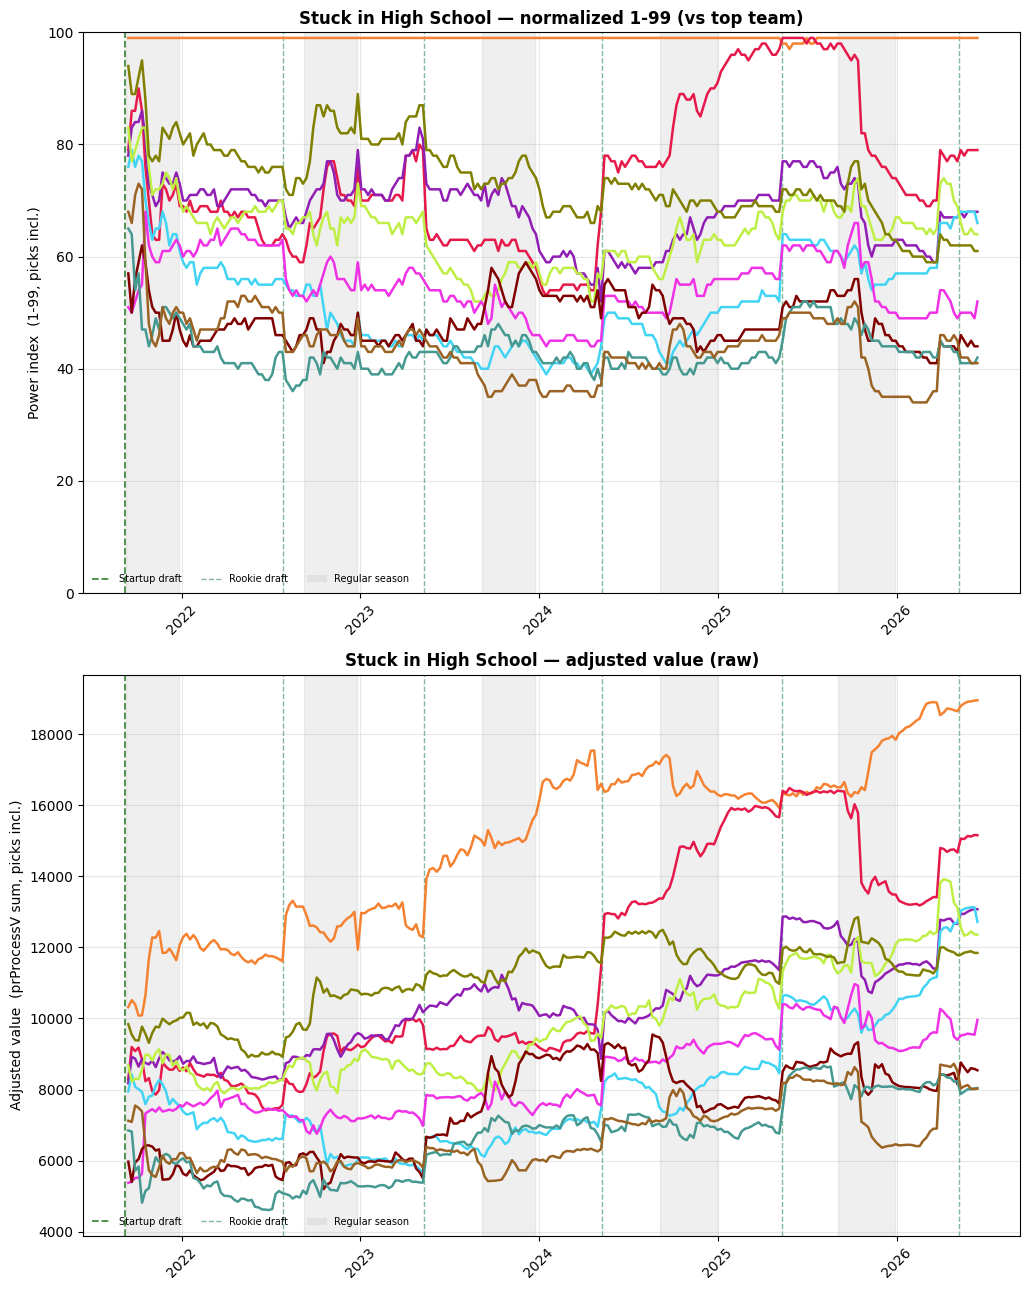

In [4]:
plot_league_both("730630605066371072")   # Stuck in High School
plt.show()

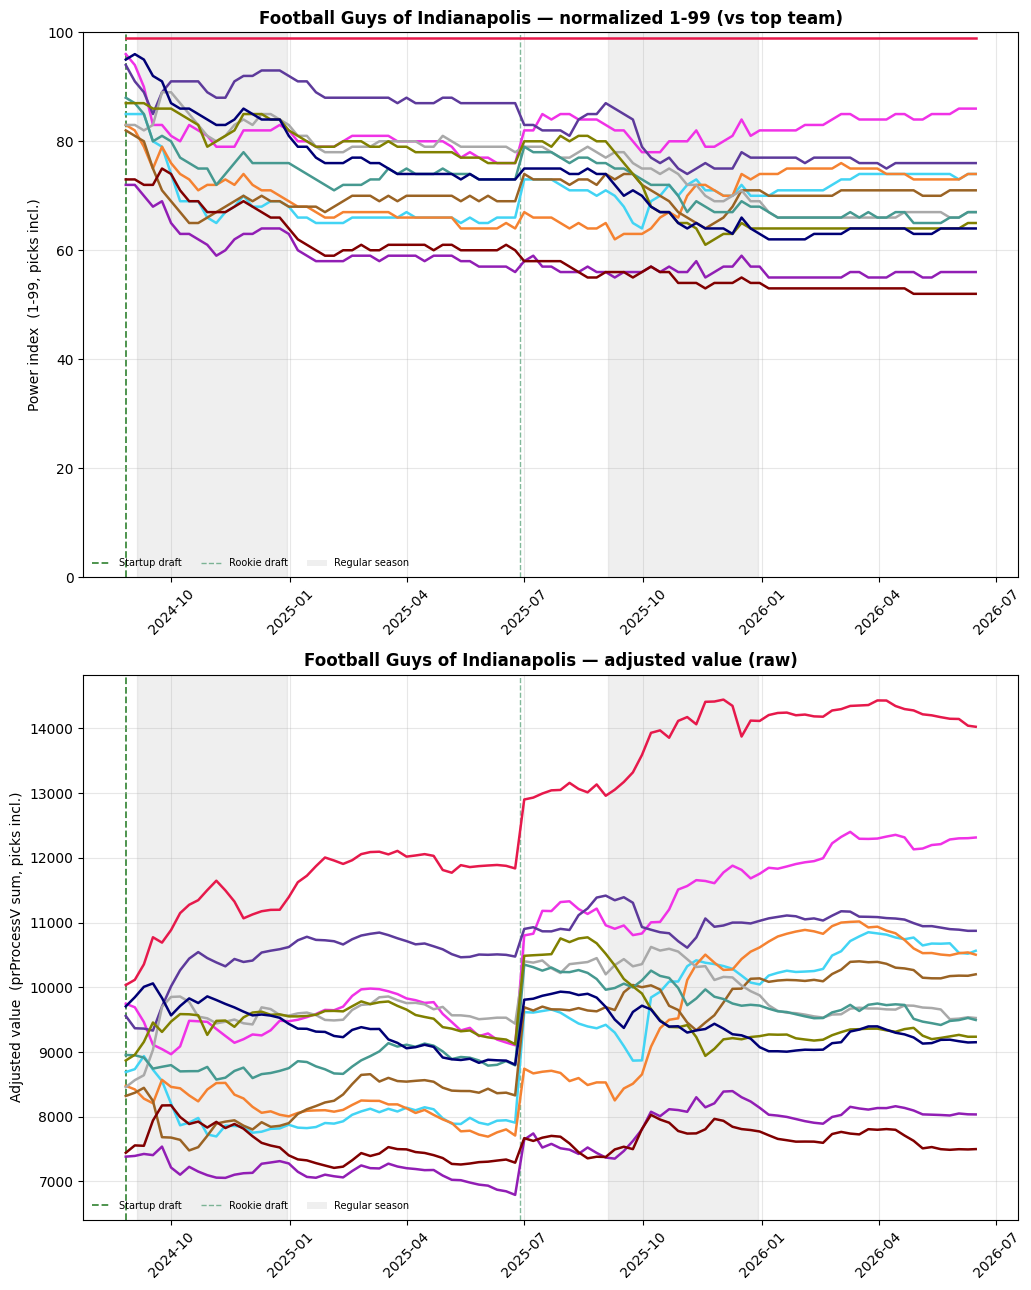

In [5]:
plot_league_both("1131624152349323264")  # Football Guys of Indianapolis
plt.show()

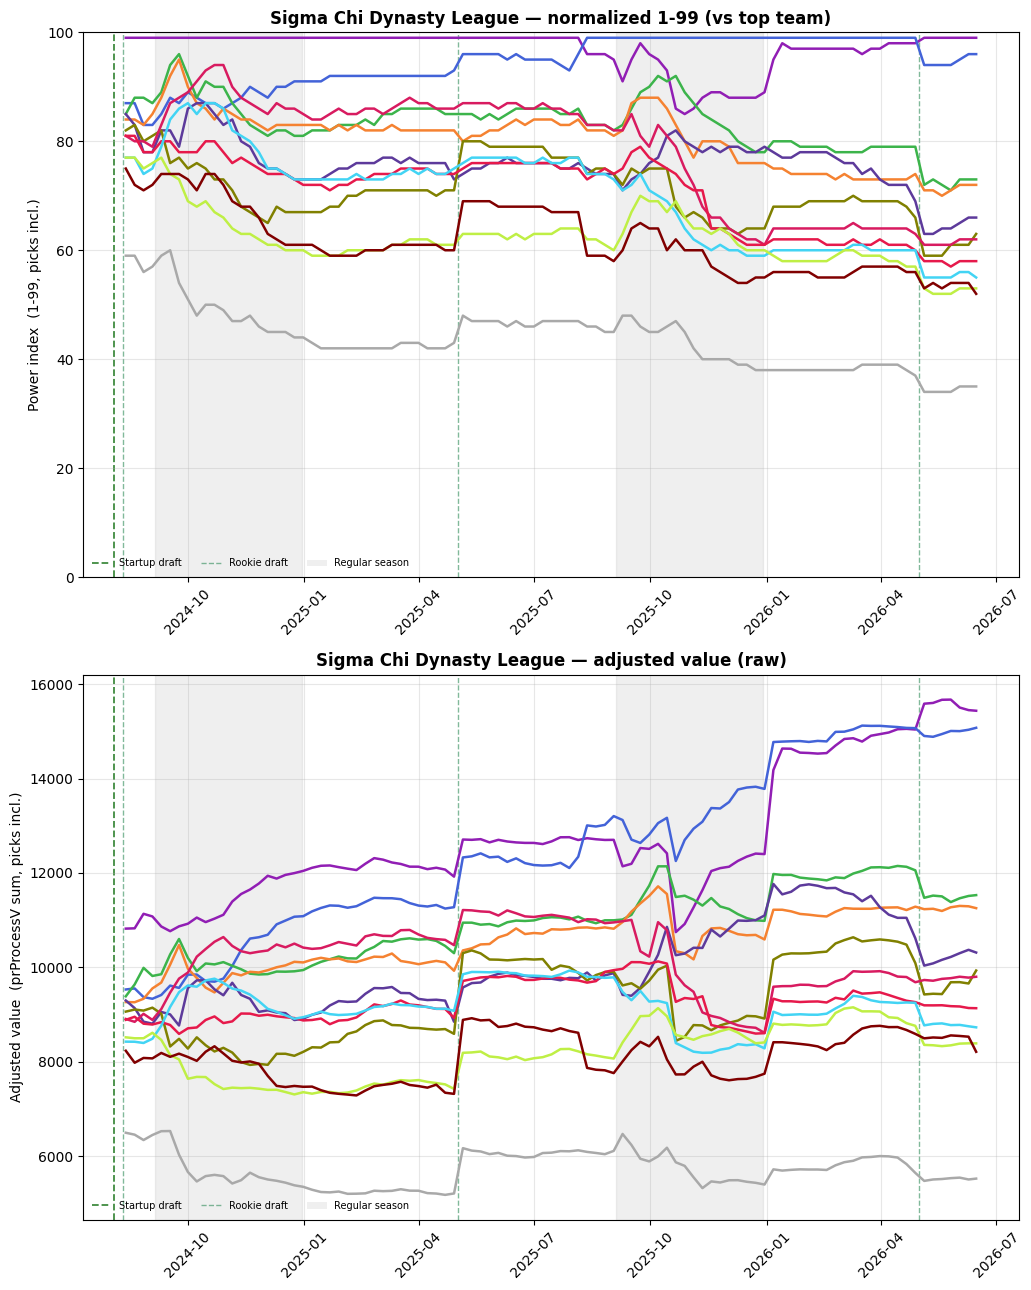

In [6]:
plot_league_both("1061511485920354304")  # Sigma Chi Dynasty League
plt.show()